In [1]:
import astropy.io.fits as pf
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

In [2]:
### data 
### https://www.dropbox.com/scl/fi/5pmz5z2h13381duajnrzr/BGS_ANY_full_noveto_good_z_cut_CIGALE_small.fits?rlkey=syw7r2sk82yk4vgh23ozonc2d&e=1&dl=0

### Reloading DESI BGS galaxy catalog with CIGALE SED fitting information

In [3]:
data = pf.open('../data/BGS_ANY_full_noveto_good_z_cut_CIGALE_small_SERSIC.fits')

### Print out the information in the catalog

In [4]:
print(data[1].data.names)

['TARGETID_1', 'MWS_TARGET', 'SUBPRIORITY', 'PRIORITY_INIT', 'TARGET_STATE', 'TIMESTAMP', 'LOCATION', 'TILEID', 'TILELOCID', 'LASTNIGHT', 'Z_1', 'ZERR', 'ZWARN', 'CHI2_1', 'COEFF', 'NPIXELS', 'SPECTYPE_1', 'SUBTYPE', 'NCOEFF', 'DELTACHI2', 'FIBER', 'COADD_FIBERSTATUS', 'FIBERASSIGN_X', 'FIBERASSIGN_Y', 'PRIORITY', 'COADD_NUMEXP', 'COADD_EXPTIME', 'COADD_NUMNIGHT', 'MEAN_DELTA_X', 'RMS_DELTA_X', 'MEAN_DELTA_Y', 'RMS_DELTA_Y', 'MEAN_PSF_TO_FIBER_SPECFLUX', 'TSNR2_ELG_B', 'TSNR2_LYA_B', 'TSNR2_BGS_B', 'TSNR2_QSO_B', 'TSNR2_LRG_B', 'TSNR2_ELG_R', 'TSNR2_LYA_R', 'TSNR2_BGS_R', 'TSNR2_QSO_R', 'TSNR2_LRG_R', 'TSNR2_ELG_Z', 'TSNR2_LYA_Z', 'TSNR2_BGS_Z', 'TSNR2_QSO_Z', 'TSNR2_LRG_Z', 'TSNR2_ELG', 'TSNR2_LYA', 'TSNR2_BGS', 'TSNR2_QSO', 'TSNR2_LRG', 'ZWARN_MTL', 'Z_QN', 'Z_QN_CONF', 'IS_QSO_QN', 'PRIORITY_ASSIGNED', 'GOODPRI', 'GOODHARDLOC', 'LOCATION_ASSIGNED', 'TILELOCID_ASSIGNED', 'NTILE', 'TILES', 'TILELOCIDS', 'BRICKID', 'BRICKNAME', 'MORPHTYPE', 'RA_1', 'DEC_1', 'DCHISQ', 'EBV', 'FLUX_G_1',

### Observed magntidues with reddening correction

In [5]:
mag_g = 22.5-2.5*np.log10(data[1].data['FLUX_G_1']/data[1].data['MW_TRANSMISSION_G_1'])
mag_r = 22.5-2.5*np.log10(data[1].data['FLUX_R_1']/data[1].data['MW_TRANSMISSION_R_1'])
mag_z = 22.5-2.5*np.log10(data[1].data['FLUX_Z_1']/data[1].data['MW_TRANSMISSION_Z_1'])

### Absolute magnitudes

In [6]:
abs_g = -2.5*np.log10(data[1].data['LNU_G'])+34.1
abs_r = -2.5*np.log10(data[1].data['LNU_R'])+34.1
abs_z = -2.5*np.log10(data[1].data['LNU_Z'])+34.1

/tmp/ipykernel_22046/778660818.py:1: RuntimeWarning: invalid value encountered in log10
  abs_g = -2.5*np.log10(data[1].data['LNU_G'])+34.1
/tmp/ipykernel_22046/778660818.py:2: RuntimeWarning: invalid value encountered in log10
  abs_r = -2.5*np.log10(data[1].data['LNU_R'])+34.1
/tmp/ipykernel_22046/778660818.py:3: RuntimeWarning: invalid value encountered in log10
  abs_z = -2.5*np.log10(data[1].data['LNU_Z'])+34.1


### observed color-redshift relation

Text(0.5, 0, 'Redshift')

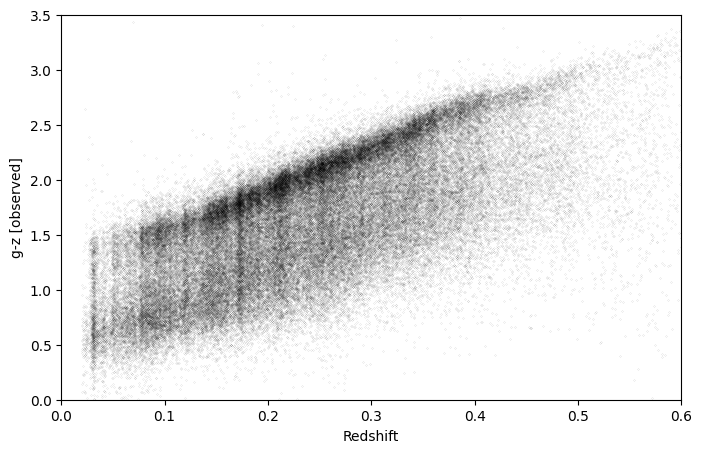

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(data[1].data['Z_1'],(mag_g-mag_z),s=0.002,color='black')

plt.xlim(0,0.6)
plt.ylim(0,3.5)
plt.ylabel('g-z [observed]')
plt.xlabel('Redshift')

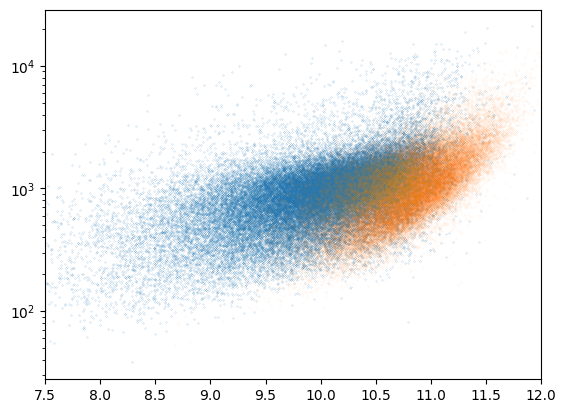

In [8]:
cut = ((abs_g-abs_z)<1.1) #& (data[1].data['Z_1']<0.1)
plt.scatter(data[1].data['LOGM'][cut],data[1].data['SHAPE_R'][cut]*cosmo.angular_diameter_distance(data[1].data['Z_1'][cut]),s=0.01)

cut = ((abs_g-abs_z)>1.1) #& (data[1].data['Z_1']<0.1)
plt.scatter(data[1].data['LOGM'][cut],data[1].data['SHAPE_R'][cut]*cosmo.angular_diameter_distance(data[1].data['Z_1'][cut]),s=0.001)

plt.xlim(7.5,12)
#plt.ylim(0,10)
plt.yscale('log')

### Absolute color-redshift relation

Text(0.5, 0, 'Redshift')

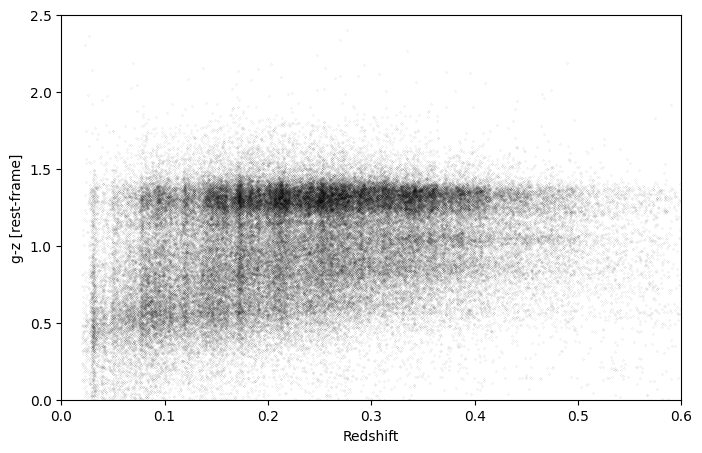

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(data[1].data['Z_1'],(abs_g-abs_z),s=0.002,color='black')
plt.xlim(0,0.6)
plt.ylim(0,2.5)
plt.ylabel('g-z [rest-frame]')
plt.xlabel('Redshift')


# HW1

## 1. We discuss that there are correlations between galaxy stellar mass, colors, morphology and sizes. In the following, we are going to use DESI data to explore some of the relationships. 
### 1.1 Select blue galaxies with g-z<1.1 (rest-frame) and plot the their distribution of SERSIC index [column "SERSIC"]
### 1.2 Select red galaxies with g-z>1.1 (rest-frame) and plot the distribution of SERSIC index [column "SERSIC"]
### 1.3 What do you observe? Are the distributions consistent with what we discussed in the class?
### 1.4 If you find some sources which do not have the consistent properties (e.g. blue but high Sersic index). Select the first 100 sources and print their RA_1 and DEC_1 and look at their images at https://yymao.github.io/decals-image-list-tool/ . Based on your observations, what are the possible reasons for the inconsistency?
### 1.5 We now explore the size distribution of galaxies. column SHAPE_R (arcsec) provides the observed sizes of galaxies. Convert them into physical sizes in unit of kpc (check the angular diameter distance and the unit in astropy document). 
### Plot x-axis (stellar mass LOGM) and y-axis galaxy sizes for blue galaxies (g-z<1.1) and red galaxies (g-z>1.1). (ignore the data with LOGM<7.5). What do you observe? Are the results consistent with what we discussed?
### 1.6 Plot x-axis redshifts (Z_1) and y-axis stellar mass (LOGM) [Again ignore the data with LOGM<7.5]. There is a trend between stellar mass and redshifts. What causes such a trend?

### 1.7 Plot stellar mass (x-axis) to color g-z relation (y-axis). You will find that there are fewer red galaxies at lower mass end. What is the reason for this behavior?

### 1.8 We now explore the mass-to-light ratio. Plot M/L ratio (y-axis) and g-r (absolute color, x-axis). [To do so, you need to convert LNU_G [W/Hz] into the unit of solar luminosity in G band.] Is your result consistent with Fig 6 of Bell et al. (2003) [https://arxiv.org/pdf/astro-ph/0302543]? Do you observe any differences?

### 1.9 Color the M/L vs g-r scatter plot with stellar mass. Is there a mass-dependent trend for the M/L ratio?

### 1.10 Based on the information provided by the catalog, calculate and plot the K-correction for g, r, z bands (y-axis) as a function of redshift (x-axis) [3 figures] and color code the data points with the g-z color. Do you observe any color dependence on the K-correction? Are your results consistent with Fukugita et al. (1995)?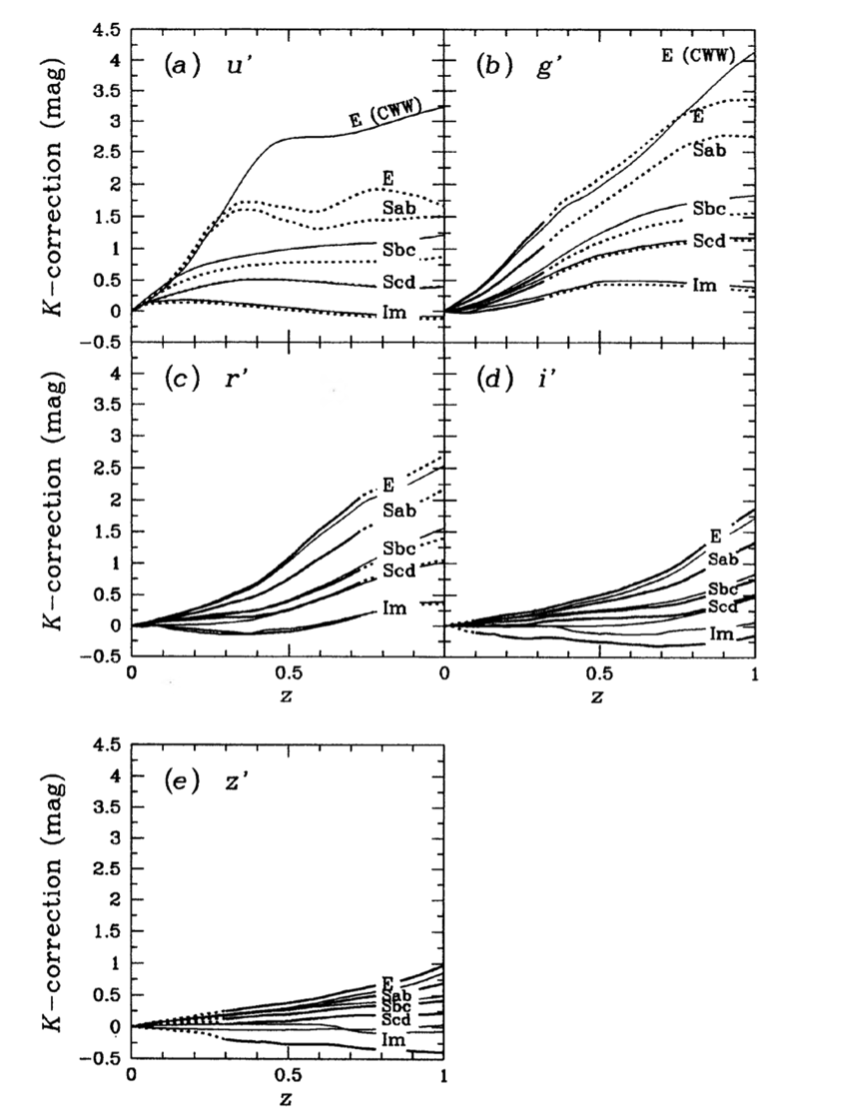) 



